# Aggregazione risultati battery run

This notebook aggregates the `battery_results_*.csv` files produced by each run in `tests/battery/results/`, adds the run identifier (`cf0`, `cfg0`, ...) and the execution parameters extracted from the respective `battery_config.json`.

In [25]:
from pathlib import Path
import json
import pandas as pd
import re

# The working directory of the kernel can be either the repo root or the notebook folder.
# We select the root robustly by looking for tests/battery/results.
candidate_root = Path().resolve()
if (candidate_root / "tests" / "battery" / "results").exists():
    REPO_ROOT = candidate_root
else:
    # Il notebook è in tests/battery: saliamo di due livelli
    REPO_ROOT = candidate_root.parents[1]

RESULTS_DIR = REPO_ROOT / "tests" / "battery" / "results"

# Get folders that look like runs
# prefix_regex = r"^(cf|cfg)\d+_"
# get only cfg runs
prefix_regex = r"^(cfg)\d+_"
run_dirs = sorted(
    d for d in RESULTS_DIR.iterdir()
    if d.is_dir() and re.match(prefix_regex, d.name)
)
print(f"Trovate {len(run_dirs)} run directories")
for d in run_dirs:
    print(" -", d.name)


Trovate 12 run directories
 - cfg0_0713_1442_1_roll0_0_T_S
 - cfg10_0713_2343_20_roll4_0_T_S
 - cfg11_0714_0035_20_roll4_0_T_M
 - cfg1_0713_1556_1_roll0_0_T_M
 - cfg2_0713_1724_8_roll0_0_T_S
 - cfg3_0713_1753_8_roll0_0_T_M
 - cfg4_0713_1823_20_roll0_0_T_S
 - cfg5_0713_1857_20_roll0_0_T_M
 - cfg6_0713_1927_1_roll4_0_T_S
 - cfg7_0713_2042_1_roll4_0_T_M
 - cfg8_0713_2157_8_roll4_0_T_S
 - cfg9_0713_2249_8_roll4_0_T_M


In [26]:
def load_run(run_dir: Path) -> pd.DataFrame:
    """Loads the results of a run and adds metadata."""
    run_id = run_dir.name.split("_")[0]

    config_path = run_dir / "battery_config.json"
    cfg = json.loads(config_path.read_text()) if config_path.exists() else {}

    # Find the battery_results CSV
    csv_files = list(run_dir.glob("battery_results_*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Nessun battery_results CSV trovato in {run_dir}")
    csv_path = csv_files[0]

    df = pd.read_csv(csv_path)
    df.insert(0, "run_id", run_id)
    df["rollback_max_consecutive"] = cfg.get("rollback_max_consecutive")
    df["parallelism"] = cfg.get("max_batch_solver_parallelism")
    df["online_swarm_mode"] = cfg.get("online_swarm_mode")

    # Join with per_n_timings (elapsed_seconds per scenario/mode/batch_size)
    timing_files = list(run_dir.glob("per_n_timings_*.csv"))
    if timing_files:
        timings = pd.read_csv(timing_files[0])
        # Align naming with battery_results CSV columns
        timings = timings.rename(
            columns={
                "elapsed_seconds": "elapsed_seconds",
                "mode": "infeasibility_mode",
            }
        )
        # battery_results uses "batch_size"; per_n_timings also uses "batch_size"
        df = df.merge(
            timings[["scenario_id", "infeasibility_mode", "batch_size", "elapsed_seconds"]],
            on=["scenario_id", "infeasibility_mode", "batch_size"],
            how="left",
        )

    return df


dfs = [load_run(d) for d in run_dirs]
df_all = pd.concat(dfs, ignore_index=True)

# Rename carbon cost column for brevity
df_all = df_all.rename(columns={"total_carbon_cost": "carbon_cost"})
# rename carbon_cost_saving_vs_baseline_pct to carbon_saving for brevity
df_all = df_all.rename(columns={"carbon_cost_saving_vs_baseline_pct": "carbon_saving"})
# # rename max_batch_solver_parallelism to parallelism for brevity
# df_all = df_all.rename(columns={"max_batch_solver_parallelism": "parallelism"})

print(f"Righe totali: {len(df_all)}")
print(f"Colonne: {list(df_all.columns)}")


Righe totali: 3720
Colonne: ['run_id', 'scenario_id', 'backend', 'batch_size', 'infeasibility_mode', 'solver_time_ms_avg', 'carbon_cost', 'final_global_error', 'avg_global_error_per_slot', 'requests_assigned_with_greedy_fallback', 'requests_assigned_with_relaxed_retry', 'total_rollbacks', 'max_consecutive_rollbacks', 'baseline_total_carbon_cost', 'carbon_saving', 'peak_concurrent_workers', 'avg_concurrent_workers', 'rollback_max_consecutive', 'parallelism', 'online_swarm_mode', 'elapsed_seconds']


In [27]:
# set to display all colmuns 
pd.set_option("display.max_columns", None)

# Preview of the aggregated data
display(df_all.head())

# Save the aggregated dataframe
output_csv = RESULTS_DIR / "aggregated_battery_results.csv"
df_all.to_csv(output_csv, index=False)
print(f"Salvato in: {output_csv}")


,run_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,rollback_max_consecutive,parallelism,online_swarm_mode,elapsed_seconds
0,cfg0,low_load_2028,rust,1,greedy_fallback,0.085967,1137.994740,3.996049,3.998442,0,0,0,0,5119.102429,77.769643,1,1.0,0,1,serialized,2.367
1,cfg0,low_load_2028,rust,4,greedy_fallback,1.564281,1070.971295,3.997845,4.017944,0,0,0,0,5119.102429,79.078924,1,1.0,0,1,serialized,1.661
2,cfg0,low_load_2028,rust,6,greedy_fallback,7.754963,1147.067140,3.987069,4.001394,0,0,0,0,5119.102429,77.592417,1,1.0,0,1,serialized,3.008
3,cfg0,low_load_2028,rust,8,greedy_fallback,17.456117,1257.204302,3.963721,3.961054,0,0,0,0,5119.102429,75.440923,1,1.0,0,1,serialized,4.610
4,cfg0,low_load_2028,rust,10,greedy_fallback,29.030255,1239.448192,3.958333,3.944802,0,0,0,0,5119.102429,75.787783,1,1.0,0,1,serialized,5.865


Salvato in: /home/francis/unipi/carbonshift/carbonshift/tests/battery/results/aggregated_battery_results.csv


# Analysis section

This is a section I used to get some statistics and plots from the aggregated data with the purpose of gathering insights on the performance of the different configurations. 

In [28]:
# get max of requests_assigned_with_greedy_fallback
df_all["requests_assigned_with_greedy_fallback"].max()
# df_all["requests_assigned_with_relaxed_retry"].max()



np.int64(0)

In [29]:
# Sort by scenario_id and then by carbon cost
df_all_sorted_by_scenario = df_all.sort_values(by=["scenario_id", "carbon_cost"])
# Get only the first 5 rows for each scenario_id (the one with the lowest carbon cost)
df_top5_per_scenario = df_all_sorted_by_scenario.groupby("scenario_id").head(5)

# Filter to get infeasibility_mode = "greedy_fallback"|"relaxed_retry"
df_filtered = df_all_sorted_by_scenario[
    df_all_sorted_by_scenario["infeasibility_mode"].isin(["greedy_fallback", "relaxed_retry"])
]

# display up to 200 rows
pd.set_option("display.max_rows", 200)

df_top5_per_scenario.head(5)


,run_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,rollback_max_consecutive,parallelism,online_swarm_mode,elapsed_seconds
2954,cfg7,high_load_105,rust,6,relaxed_retry,8.291271,5025.971597,4.000158,4.01234,0,330,0,0,22935.935562,78.086913,1,1.0,4,1,merge,10.603
2644,cfg6,high_load_105,rust,6,relaxed_retry,7.702213,5025.996525,4.000158,4.01234,0,330,0,0,22935.935562,78.086804,1,1.0,4,1,serialized,9.881
2947,cfg7,high_load_105,rust,6,greedy_fallback,7.891386,5027.052729,4.000158,4.01234,0,0,0,0,22935.935562,78.082199,1,1.0,4,1,merge,10.195
164,cfg0,high_load_105,rust,6,relaxed_retry,7.472908,5028.457070,4.000158,4.01234,0,330,0,0,22935.935562,78.076076,1,1.0,0,1,serialized,9.636
157,cfg0,high_load_105,rust,6,greedy_fallback,7.522535,5028.575486,4.000158,4.01234,0,0,0,0,22935.935562,78.075560,1,1.0,0,1,serialized,9.737


## Relaxed retry vs greedy fallback

In [30]:

# Count relaxed_retry vs greedy_fallback in the top 5 per scenario
count_modes = df_top5_per_scenario["infeasibility_mode"].value_counts()
print(count_modes)

# Avg elapsed_seconds per mode 
# get rows where infeasibility_mode does not include "offline"
df_online_modes = df_all[~df_all["infeasibility_mode"].str.contains("offline")]
avg_elapsed_seconds_per_mode = df_online_modes.groupby("infeasibility_mode")["elapsed_seconds"].mean()
print(avg_elapsed_seconds_per_mode)
avg_elapsed_seconds_per_mode = df_top5_per_scenario.groupby("infeasibility_mode")["elapsed_seconds"].mean()
print(avg_elapsed_seconds_per_mode)

# Avg carbon cost per mode
avg_carbon_cost_per_mode = df_online_modes.groupby("infeasibility_mode")["carbon_cost"].mean()
print(avg_carbon_cost_per_mode)



infeasibility_mode
relaxed_retry      26
greedy_fallback    24
Name: count, dtype: int64
infeasibility_mode
greedy_fallback      14.236057
online_ant_colony     2.170088
online_bandit         2.790960
relaxed_retry        25.259918
Name: elapsed_seconds, dtype: float64
infeasibility_mode
greedy_fallback    7.284625
relaxed_retry      7.327154
Name: elapsed_seconds, dtype: float64
infeasibility_mode
greedy_fallback      6114.666692
online_ant_colony    9169.613477
online_bandit        7631.486387
relaxed_retry        6115.033030
Name: carbon_cost, dtype: float64


In [31]:
# install seaborn
# !pip install seaborn

###

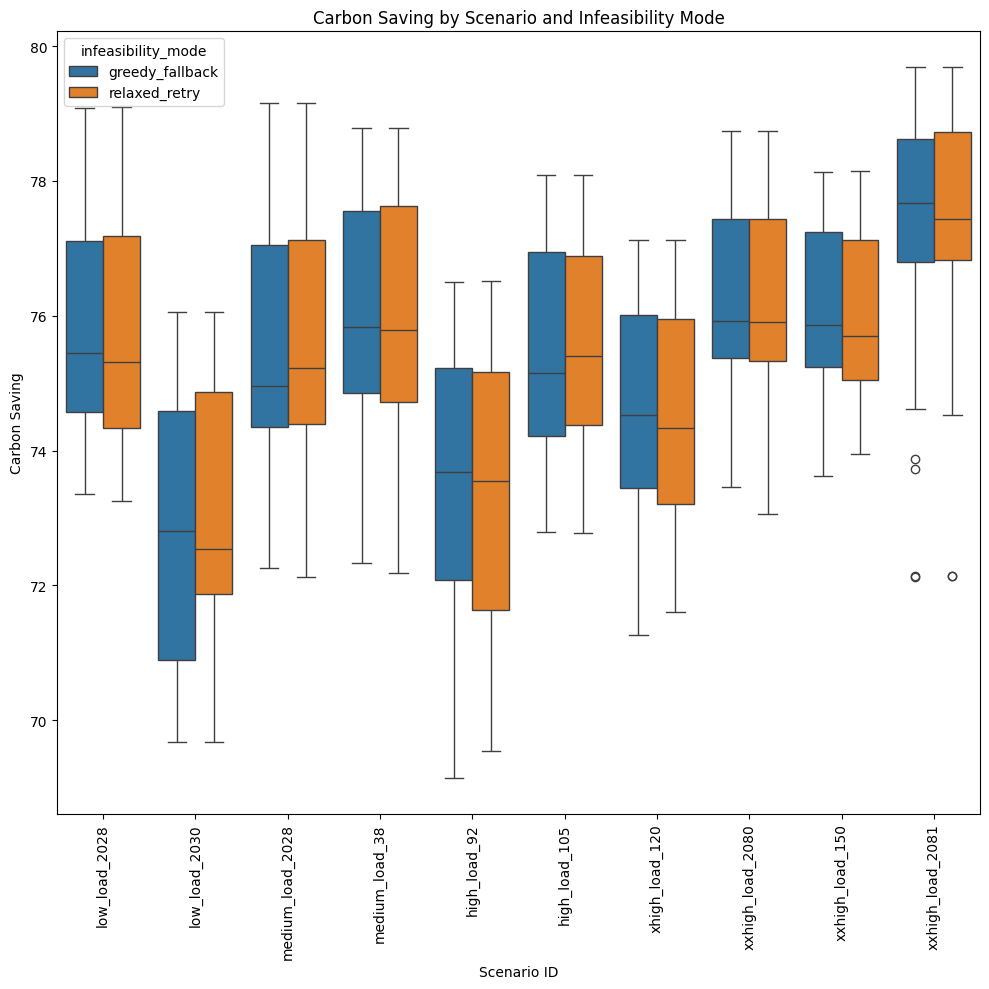

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt


df_gr_ret = df_all[~df_all["infeasibility_mode"].str.contains("offline|online")]
plt.figure(figsize=(10,10))


sns.boxplot(
    data=df_gr_ret,
    x="scenario_id",
    y="carbon_saving",
    hue="infeasibility_mode",
    showfliers=True,
)

plt.xlabel("Scenario ID")
plt.ylabel("Carbon Saving")
plt.title("Carbon Saving by Scenario and Infeasibility Mode")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Relaxed retry vs greedy fallback
Overall greedy fallback is in general faster and yields the same results as relaxed retry.\
However, considering only top 5 runs per scenario, both the carbon cost and the elapsed time are basically the same.\
In general, it could be better to use greedy fallback, as it is faster and yields the same results.

These tests were run with the following `relaxed_retry` parameters:
```
infeasibility_recovery_mode: "carryover_last_slot".to_string(),
infeasibility_mock_influence: 0.6,
infeasibility_mock_influence_decay_step: 0.15,
```
That is, in case of infeasibility, the algorithm will consider the previous slot's assignment with a weight of 0.6 to influence the current slot's assignment. The weight will decay by 0.15 at every subsequent slot where infeasibility occurs. This means that the algorithm will try to "carry over" the previous slot's assignment to the current slot, but with decreasing influence as more infeasibility occurs.\
The mechanism is designed to help the solver not to "panic" and try to assign requests knowing that others will come, allowing to mitigate the error average.

This probably results in being only partially effective due to the decayed window, which kind of embeds this idea already.


## Rollback and Parallelism


In [33]:
# Let's understand if more parallelism yields less elapsed_time
# Get only relaxed_retry and greedy_fallback modes
df_gr_ret = df_all[~df_all["infeasibility_mode"].str.contains("offline|online")]
# For each scenario and for each N, we want to know a much elapsed_time is spared with runs having parallelism > 1 compared to runs with parallelism = 1
group_cols = ["scenario_id", "batch_size"]

# Baseline: prendiamo il max elapsed_seconds tra le run con parallelism=1
baseline = (
    df_gr_ret[df_gr_ret["parallelism"] == 1]
    .groupby(group_cols)
    .agg(
        elapsed_parallelism_1=("elapsed_seconds", "max"),
    )
    .reset_index()
)

# Run con parallelism > 1
parallel = (
    df_gr_ret[df_gr_ret["parallelism"] > 1]
    [
        group_cols
        + [
            "parallelism",
            "elapsed_seconds",
            "peak_concurrent_workers",
            "avg_concurrent_workers",
            "infeasibility_mode",
            "rollback_max_consecutive",
            "total_rollbacks",
            "carbon_saving"
        ]
    ]
)

# confronto
comparison = parallel.merge(
    baseline,
    on=group_cols,
    how="inner",
)

comparison["seconds_saved"] = (
    comparison["elapsed_parallelism_1"]
    - comparison["elapsed_seconds"]
)

comparison["speedup_pct"] = (
    comparison["seconds_saved"]
    / comparison["elapsed_parallelism_1"]
    * 100
)

# Set columns ordering for comparison for better readability
comparison = comparison[
    [
        "scenario_id",
        "batch_size",
        "parallelism",
        "elapsed_seconds",
        "elapsed_parallelism_1",
        "seconds_saved",
        "speedup_pct",
        "carbon_saving",
        "peak_concurrent_workers",
        "avg_concurrent_workers",
        "infeasibility_mode",
        "rollback_max_consecutive",
        "total_rollbacks",
    ]
] 

comparison.head()
# comparison
# display for scenario xxhigh_load_2081
display(comparison[(comparison["scenario_id"] == "xxhigh_load_2081") & (comparison["batch_size"] == 16)].tail(4))
display(comparison[(comparison["scenario_id"] == "high_load_105") & (comparison["batch_size"] == 16)])
display(comparison[(comparison["scenario_id"] == "low_load_2028") & (comparison["batch_size"] == 16)])


summary = (
    comparison
    .groupby("parallelism")
    .agg(
        runs=("scenario_id", "count"),
        avg_saved_seconds=("seconds_saved", "mean"),
        median_saved_seconds=("seconds_saved", "median"),
        avg_speedup_pct=("speedup_pct", "mean"),
        median_speedup_pct=("speedup_pct", "median"),
        avg_peak_workers=("peak_concurrent_workers", "mean"),
        avg_workers=("avg_concurrent_workers", "mean"),
        avg_rollbacks=("total_rollbacks", "mean"),
    )
)

summary

,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,infeasibility_mode,rollback_max_consecutive,total_rollbacks
972,xxhigh_load_2081,16,8,51.924,238.092,186.168,78.191623,76.680624,8,5.823144,greedy_fallback,4,483
979,xxhigh_load_2081,16,8,211.053,238.092,27.039,11.356534,76.336533,8,5.824236,relaxed_retry,4,446
1112,xxhigh_load_2081,16,8,502.821,238.092,-264.729,-111.187692,76.554648,8,5.818975,greedy_fallback,4,523
1119,xxhigh_load_2081,16,8,195.637,238.092,42.455,17.831343,76.508067,8,5.827511,relaxed_retry,4,448


,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,infeasibility_mode,rollback_max_consecutive,total_rollbacks
76,high_load_105,16,20,34.352,125.325,90.973,72.589667,73.773127,12,3.878505,greedy_fallback,4,319
83,high_load_105,16,20,122.327,125.325,2.998,2.392180,73.919734,12,3.876168,relaxed_retry,4,292
216,high_load_105,16,20,34.484,125.325,90.841,72.484341,74.235251,12,3.878505,greedy_fallback,4,327
223,high_load_105,16,20,123.250,125.325,2.075,1.655695,73.734222,12,3.876168,relaxed_retry,4,287
356,high_load_105,16,8,14.025,125.325,111.300,88.809096,75.094603,8,3.803738,greedy_fallback,0,0
363,high_load_105,16,8,62.006,125.325,63.319,50.523838,75.221021,8,3.803738,relaxed_retry,0,0
496,high_load_105,16,8,14.771,125.325,110.554,88.213844,75.212637,8,3.803738,greedy_fallback,0,0
503,high_load_105,16,8,55.180,125.325,70.145,55.970477,75.226391,8,3.801402,relaxed_retry,0,0
636,high_load_105,16,20,14.370,125.325,110.955,88.533812,74.718749,12,3.878505,greedy_fallback,0,0
643,high_load_105,16,20,54.731,125.325,70.594,56.328745,74.699966,12,3.878505,relaxed_retry,0,0


,scenario_id,batch_size,parallelism,elapsed_seconds,elapsed_parallelism_1,seconds_saved,speedup_pct,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,infeasibility_mode,rollback_max_consecutive,total_rollbacks
6,low_load_2028,16,20,12.079,32.53,20.451,62.868122,73.389095,3,1.458333,greedy_fallback,4,29
13,low_load_2028,16,20,28.365,32.53,4.165,12.803566,73.390155,3,1.458333,relaxed_retry,4,30
146,low_load_2028,16,20,11.840,32.53,20.690,63.602828,73.415390,3,1.458333,greedy_fallback,4,29
153,low_load_2028,16,20,28.401,32.53,4.129,12.692899,73.415789,3,1.458333,relaxed_retry,4,31
286,low_load_2028,16,8,7.659,32.53,24.871,76.455579,73.772513,3,1.458333,greedy_fallback,0,0
293,low_load_2028,16,8,18.871,32.53,13.659,41.988933,73.810837,3,1.458333,relaxed_retry,0,0
426,low_load_2028,16,8,7.947,32.53,24.583,75.570243,73.772513,3,1.458333,greedy_fallback,0,0
433,low_load_2028,16,8,20.047,32.53,12.483,38.373809,73.801237,3,1.458333,relaxed_retry,0,0
566,low_load_2028,16,20,8.031,32.53,24.499,75.312020,73.772513,3,1.458333,greedy_fallback,0,0
573,low_load_2028,16,20,19.607,32.53,12.923,39.726406,73.781796,3,1.458333,relaxed_retry,0,0


,runs,avg_saved_seconds,median_saved_seconds,avg_speedup_pct,median_speedup_pct,avg_peak_workers,avg_workers,avg_rollbacks
parallelism,,,,,,,,
8,560,20.571464,8.3315,52.087344,60.364185,7.521429,4.772091,138.266071
20,560,20.470175,7.8750,53.793748,60.223396,15.767857,6.341323,181.700000


### Commenti su rollback e parallelismo
Per lo scenario a bassa intensità sembra che rollback non porti vantaggi in termini di risparmio carbonio, mentre per lo scenario ad alta intensità sembra che rollback porti a un risparmio di carbonio maggiore, di circa 3-4% rispetto a non usare rollback con parallelismo a 20 worker, mentre nessun vantaggio con parallelismo a 8 worker.

Non sembra ci sia significativo vantaggio nell'usare parallelismo a 20 worker rispetto a 8 worker.

In generale il parallelismo porta a un significativo risparmio di tempo di esecuzione.

I rollback *non* sembrano indurre un significativo risparmio di carbonio.

Il tempo di esecuzione sembra poter aver subito influenza di fattori esterni, come la disponibilità di risorse della macchina, che può aver influito sul parallelismo e quindi sul tempo di esecuzione. Questo è alquanto spiacevole.


In [34]:
    # Count values of rollback_max_consecutive and parallelism for the top 5 per scenario
count_rollback_max_consecutive = df_top5_per_scenario["rollback_max_consecutive"].value_counts()
count_parallelism = df_top5_per_scenario["parallelism"].value_counts()
#average roll

print("Count of rollback_max_consecutive in top 5 per scenario:")
print(count_rollback_max_consecutive)
print("\nCount of parallelism in top 5 per scenario:")
print(count_parallelism)

Count of rollback_max_consecutive in top 5 per scenario:
rollback_max_consecutive
0    26
4    24
Name: count, dtype: int64

Count of parallelism in top 5 per scenario:
parallelism
1    50
Name: count, dtype: int64


Non incredibilmente, sembra che i migliori risultati si ottengano con parallelismo a 1, non c'è concorrenza e non c'è rischio di fare assegnamenti basati su informazioni stale, potenzialmente sforando un cap level e avendo un costo superiore a quello previsto.

In [35]:
# get top5 but filter out parallelism = 1
df_all_sorted_by_scenario_filtered = df_all_sorted_by_scenario[df_all_sorted_by_scenario["parallelism"] != 1]
df_top5_per_scenario = df_all_sorted_by_scenario_filtered.groupby("scenario_id").head(5)

df_top5_per_scenario

,run_id,scenario_id,backend,batch_size,infeasibility_mode,solver_time_ms_avg,carbon_cost,final_global_error,avg_global_error_per_slot,requests_assigned_with_greedy_fallback,requests_assigned_with_relaxed_retry,total_rollbacks,max_consecutive_rollbacks,baseline_total_carbon_cost,carbon_saving,peak_concurrent_workers,avg_concurrent_workers,rollback_max_consecutive,parallelism,online_swarm_mode,elapsed_seconds
1713,cfg3,high_load_105,rust,4,relaxed_retry,4.056991,5159.528259,3.992273,3.996164,0,152,0,0,22935.935562,77.504610,8,5.919255,0,8,merge,2.174
466,cfg10,high_load_105,rust,4,greedy_fallback,4.670425,5161.694522,4.002523,4.004423,0,0,466,4,22935.935562,77.495165,20,8.275776,4,20,serialized,2.780
3573,cfg9,high_load_105,rust,4,relaxed_retry,3.271871,5170.804832,3.998975,3.999139,0,2,350,4,22935.935562,77.455444,8,5.995031,4,8,merge,2.285
1396,cfg2,high_load_105,rust,4,greedy_fallback,4.394298,5172.467745,3.995427,4.002712,0,0,0,0,22935.935562,77.448194,8,5.967702,0,8,serialized,2.277
3256,cfg8,high_load_105,rust,4,greedy_fallback,4.157276,5177.774030,3.994638,4.003974,0,0,355,4,22935.935562,77.425059,8,6.121739,4,8,serialized,2.682
450,cfg10,high_load_92,rust,0,offline_ant_colony,0.000000,3177.872189,3.975231,4.014128,0,0,0,0,13202.749373,75.930224,0,0.000000,4,20,serialized,0.602
760,cfg11,high_load_92,rust,0,offline_ant_colony,0.000000,3177.872189,3.975231,4.014128,0,0,0,0,13202.749373,75.930224,0,0.000000,4,20,merge,0.597
1380,cfg2,high_load_92,rust,0,offline_ant_colony,0.000000,3177.872189,3.975231,4.014128,0,0,0,0,13202.749373,75.930224,0,0.000000,0,8,serialized,0.584
1690,cfg3,high_load_92,rust,0,offline_ant_colony,0.000000,3177.872189,3.975231,4.014128,0,0,0,0,13202.749373,75.930224,0,0.000000,0,8,merge,0.565
2000,cfg4,high_load_92,rust,0,offline_ant_colony,0.000000,3177.872189,3.975231,4.014128,0,0,0,0,13202.749373,75.930224,0,0.000000,0,20,serialized,0.546


In [38]:
# get average carbon saving for all modes
average_carbon_saving = df_all.groupby("infeasibility_mode")["carbon_saving"].mean()
display(average_carbon_saving)

# get max carbon saving value for online_ant_colony mode with parallelism = 1 and online_swarm_mode = serialized
max_carbon_saving = df_all[
    (df_all["infeasibility_mode"] == "online_ant_colony") &
    (df_all["parallelism"] == 1) &
    (df_all["online_swarm_mode"] == "serialized")
]["carbon_saving"].max()
display(max_carbon_saving)


infeasibility_mode
greedy_fallback            75.348889
offline_ant_colony         75.622140
offline_bandit             68.855905
offline_greedy_cheapest    63.499876
online_ant_colony          62.963416
online_bandit              68.988664
relaxed_retry              75.361838
Name: carbon_saving, dtype: float64

np.float64(70.08846277387023)